# importing Data Set

In [63]:
import torch
import os
import re
import plotly.express as px
import numpy as np
import pandas as pd
import cv2
from torchvision import models, transforms
from torch.nn import functional as F
import plotly.graph_objects as go

In [64]:

#Load your tabular data
tabular_data_path = 'C:/Users/Syed Muhammad Muneeb/Downloads/DataMiningDS/app_data.xlsx'
df = pd.read_excel(tabular_data_path)

# Display the first few rows of the tabular data
print(df.head())



     Age   BMI     Sex  Height  Weight  Length_of_Stay    Management  \
0  12.68  16.9  female   148.0    37.0             3.0  conservative   
1  14.10  31.9    male   147.0    69.5             2.0  conservative   
2  14.14  23.3  female   163.0    62.0             4.0  conservative   
3  16.37  20.6  female   165.0    56.0             3.0  conservative   
4  11.08  16.9  female   163.0    45.0             3.0  conservative   

        Severity Diagnosis_Presumptive        Diagnosis  ...  \
0  uncomplicated          appendicitis     appendicitis  ...   
1  uncomplicated          appendicitis  no appendicitis  ...   
2  uncomplicated          appendicitis  no appendicitis  ...   
3  uncomplicated          appendicitis  no appendicitis  ...   
4  uncomplicated          appendicitis     appendicitis  ...   

   Abscess_Location  Pathological_Lymph_Nodes Lymph_Nodes_Location  \
0               NaN                       yes                 reUB   
1               NaN                       

In [65]:
# Summary of the dataset
summary = {
    "Shape": df.shape,
    "Info": df.info(),
    "Missing Values": df.isnull().sum(),
    "Sample Data": df.head(),
}

# Separate numerical and categorical columns
numerical_columns = df.select_dtypes(include=['number']).columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# Summary of numerical and categorical columns
numerical_summary = df[numerical_columns].describe()
categorical_summary = df[categorical_columns].describe()

summary.update({
    "Numerical Columns": numerical_columns.tolist(),
    "Categorical Columns": categorical_columns.tolist(),
    "Numerical Summary": numerical_summary,
    "Categorical Summary": categorical_summary,
})

summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

{'Shape': (782, 58),
 'Info': None,
 'Missing Values': Age                                   1
 BMI                                  27
 Sex                                   2
 Height                               26
 Weight                                3
 Length_of_Stay                        4
 Management                            1
 Severity                              1
 Diagnosis_Presumptive                 2
 Diagnosis                             2
 Alvarado_Score                       52
 Paedriatic_Appendicitis_Score        52
 Appendix_on_US                        5
 Appendix_Diameter                   284
 Migratory_Pain                        9
 Lower_Right_Abd_Pain                  8
 Contralateral_Rebound_Tenderness     15
 Coughing_Pain                        16
 Nausea                                8
 Loss_of_Appetite                     10
 Body_Temperature                      7
 WBC_Count                             6
 Neutrophil_Percentage               103
 Se

In [66]:
# Calculate the total and percentage of null values in the dfset
null_values = df.isnull().sum()
null_percentage = (null_values / len(df)) * 100

# Create a summary table for columns with null values
null_summary = pd.DataFrame({
    "Column": df.columns,
    "Total_Null_Values": null_values,
    "Percentage_Null_Values": null_percentage
}).sort_values(by="Total_Null_Values", ascending=False).reset_index(drop=True)

null_summary


,Column,Total_Null_Values,Percentage_Null_Values
0,Abscess_Location,769,98.337596
1,Gynecological_Findings,756,96.675192
2,Conglomerate_of_Bowel_Loops,739,94.501279
3,Segmented_Neutrophils,728,93.094629
4,Ileus,722,92.327366
5,Perfusion,719,91.943734
6,Enteritis,716,91.560102
7,Appendicolith,713,91.176471
8,Coprostasis,711,90.920716
9,Perforation,701,89.641944


# remove columns with more than 60% null values

In [67]:
# Calculate the threshold for 60% null values
threshold = len(df) * 0.6

# Drop columns where the number of null values exceeds the threshold
df_cleaned = df.loc[:, df.isnull().sum() <= threshold]

# Display the shape of the cleaned dataframe
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)


Original shape: (782, 58)
Cleaned shape: (782, 40)


In [68]:
numerical_columns = df_cleaned.select_dtypes(include=["number"]).columns
print("Numerical Columns:")
print(numerical_columns)


Numerical Columns:
Index(['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP', 'US_Number'],
      dtype='object')


In [69]:
categorical_columns = df_cleaned.select_dtypes(include=["object", "category"]).columns
print("\nCategorical Columns:")
print(categorical_columns)



Categorical Columns:
Index(['Sex', 'Management', 'Severity', 'Diagnosis_Presumptive', 'Diagnosis',
       'Appendix_on_US', 'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Neutrophilia', 'Ketones_in_Urine', 'RBC_in_Urine',
       'WBC_in_Urine', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign',
       'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'Free_Fluids'],
      dtype='object')


In [70]:
# Remove rows where 'US_Number' has null values
df_cleaned = df_cleaned.dropna(subset=['US_Number'])


In [71]:
# Fill null values in numerical columns with the mean
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].fillna(df_cleaned[numerical_columns].mean())

# Verify if nulls have been filled
print("Null values in numerical columns after filling:")
#print(df[numerical_columns].isnull().sum())


Null values in numerical columns after filling:


In [72]:
# Fill null values in categorical columns with the mode
df_cleaned[categorical_columns] = df_cleaned[categorical_columns].apply(lambda col: col.fillna(col.mode()[0]))

# Verify if nulls have been filled
print("Null values in categorical columns after filling:")
#print(df[categorical_columns].isnull().sum())


Null values in categorical columns after filling:


In [73]:
df=df_cleaned

In [74]:
# Display the shape of the cleaned dataframe
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)


Original shape: (760, 40)
Cleaned shape: (760, 40)


In [75]:
df_cleaned[numerical_columns]

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
0,12.680000,16.900000,148.0,37.0,3.0,4.0,3.0,7.100000,37.0,7.7,68.2,5.27,14.8,12.2,254.0,0.0,882.0
1,14.100000,31.900000,147.0,69.5,2.0,5.0,4.0,7.766393,36.9,8.1,64.8,5.26,15.7,12.7,151.0,3.0,883.0
2,14.140000,23.300000,163.0,62.0,4.0,5.0,3.0,7.766393,36.6,13.2,74.8,3.98,11.4,12.2,300.0,3.0,884.0
3,16.370000,20.600000,165.0,56.0,3.0,7.0,6.0,7.766393,36.0,11.4,63.0,4.64,13.6,13.2,258.0,0.0,886.0
4,11.080000,16.900000,163.0,45.0,3.0,5.0,6.0,7.000000,36.9,8.1,44.0,4.44,12.6,13.6,311.0,0.0,887.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,7.882272,18.698225,130.0,31.6,7.0,7.0,6.0,10.000000,38.2,22.7,90.5,5.05,13.5,12.3,457.0,44.0,244.0
777,12.413415,25.250476,166.5,70.0,4.0,8.0,7.0,7.500000,39.4,11.4,76.6,4.95,13.7,13.4,243.0,71.0,126.0
779,14.992471,19.909972,152.0,46.0,4.0,5.0,3.0,7.766393,37.3,14.6,68.5,4.49,12.7,12.8,328.0,2.0,127.0
780,7.195072,14.295549,129.3,23.9,5.0,9.0,8.0,14.000000,37.5,17.8,77.0,4.97,14.3,12.7,345.0,8.0,128.0


In [76]:
# Select only numerical columns
numerical_df = df_cleaned.select_dtypes(include=['number'])
# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create the heatmap
heatmap = go.Figure(
    data=go.Heatmap(
        z=correlation_matrix.values,  # Correlation values
        x=correlation_matrix.columns,  # Column labels
        y=correlation_matrix.columns,  # Row labels
        colorscale="Viridis",  # Choose a color scale
        colorbar=dict(title="Correlation"),  # Add a color bar
        hoverongaps=False  # Display gaps in missing data
    )
)

# Update layout for better appearance
heatmap.update_layout(
    title="Correlation Heatmap for Numerical Columns",
    xaxis=dict(title="Columns", tickangle=45),  # Rotate x-axis labels
    yaxis=dict(title="Columns"),
    height=800,  # Adjust height
    width=800,  # Adjust width
    margin=dict(l=50, r=50, t=50, b=100)  # Add margin for readability
)

# Display the heatmap
heatmap.show()

In [77]:

# Assuming 'df' is your DataFrame
numerical_columns = df.select_dtypes(include=["number"]).columns

for col in numerical_columns:
    # Create the horizontal boxplot
    fig = go.Figure()

    # Add the boxplot trace
    fig.add_trace(go.Box(
        x=df[col],  # Data for the boxplot (x-axis for horizontal orientation)
        boxmean=True,  # Show the mean
        name=f"Boxplot of {col}",
        marker=dict(color='red'),
        orientation='h'  # Horizontal boxplot
    ))

    # Update layout
    fig.update_layout(
        title=f"Boxplot of {col}",
        xaxis_title="Value",  # x-axis title for the horizontal boxplot
        yaxis_title=col,      # y-axis title for the column
        template="plotly_dark",  # Optional: for a dark theme
    )

    # Show the plot
    fig.show()



In [78]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Assuming 'df' is your DataFrame
numerical_columns = df.select_dtypes(include=["number"]).columns

for col in numerical_columns:
    # Create the histogram
    fig = go.Figure()

    # Drop NaN values
    col_data = df[col].dropna()

    # Add histogram trace
    fig.add_trace(go.Histogram(
        x=col_data,
        nbinsx=30, 
        name=f"Histogram of {col}", 
        opacity=0.7, 
        marker=dict(color='blue')
    ))

    # Compute a smoothed trend using a rolling average
    sorted_col_data = np.sort(col_data)  # Sort data for a smooth curve
    rolling_window = max(len(sorted_col_data) // 50, 5)  # Rolling window size (5 or 2% of data)
    rolling_avg = pd.Series(sorted_col_data).rolling(rolling_window).mean()

    # Add smoothed trend trace
    fig.add_trace(go.Scatter(
        x=sorted_col_data[len(sorted_col_data) - len(rolling_avg.dropna()):],  # Adjust x-axis to match rolling average
        y=rolling_avg.dropna(), 
        mode='lines', 
        name=f"Smoothed Trend of {col}", 
        line=dict(color='red', width=2)
    ))

    # Update layout
    fig.update_layout(
        title=f"Distribution of {col} with Smoothed Trend",
        xaxis_title=col,
        yaxis_title="Frequency",
        template="plotly_dark",  # Optional: for a dark theme
        bargap=0.2,  # Space between bars
    )

    # Show the plot
    fig.show()


In [79]:


# Assuming 'df' is your DataFrame
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    # Create a DataFrame with value counts
    value_counts = df[col].value_counts().reset_index()
    value_counts.columns = [col, 'Count']  # Rename columns

    # Create the bar plot
    fig = go.Figure()

    # Add bar trace
    fig.add_trace(go.Bar(
        x=value_counts[col],  # Categories
        y=value_counts['Count'],  # Counts
        name=f"Distribution of {col}",
        marker=dict(color='blue'),
        text=value_counts['Count'],  # Display count values as text on top of bars
        textposition='outside',  # Position the text outside the bars
    ))

    # Update layout
    fig.update_layout(
        title=f"Distribution of {col}",
        xaxis_title=col,
        yaxis_title='Count',
        template="plotly_dark",  # Optional: for a dark theme
        uniformtext_minsize=8,
        uniformtext_mode='hide'
    )

    # Show the plot
    fig.show()


In [80]:

sex_diagnosis_counts = df_cleaned.groupby(['Sex', 'Diagnosis']).size().reset_index(name='Count')

# Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in sex_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = sex_diagnosis_counts[sex_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Sex'],  # Sex categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Sex vs Diagnosis",
    xaxis_title="Sex",
    yaxis_title="Count",
    barmode='group',  # Group bars by Sex and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


In [81]:

bins = [0, 18.5, 24.9, 29.9, 40]  # Define the BMI categories
labels = ['Underweight(0-18.5)', 'Normal weight(18.5-24.9)', 'Overweight(24.9-29.9)', 'Obesity(29.9-40)']  # Corresponding labels

df_cleaned['BMI_Category'] = pd.cut(df_cleaned['BMI'], bins=bins, labels=labels, right=False)

# Step 2: Calculate the counts for each combination of 'BMI_Category' and 'Diagnosis'
bmi_diagnosis_counts = df_cleaned.groupby(['BMI_Category', 'Diagnosis']).size().reset_index(name='Count')

# Step 3: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in bmi_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = bmi_diagnosis_counts[bmi_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['BMI_Category'],  # BMI categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="BMI vs Diagnosis",
    xaxis_title="BMI Category",
    yaxis_title="Count",
    barmode='group',  # Group bars by BMI category and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()

C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\2613016077.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [82]:

bins = [0, 4, 6, 8, 10]  # Define the Alvarado_Score categories (example ranges)
labels = ['Very Low(0-4)', 'Low(4-6)', 'Medium(6-8)', 'High(8-10)']  # Corresponding labels

df_cleaned['Alvarado_Score_Category'] = pd.cut(df_cleaned['Alvarado_Score'], bins=bins, labels=labels, right=False)

# Step 2: Calculate the counts for each combination of 'Alvarado_Score_Category' and 'Diagnosis'
alvarado_diagnosis_counts = df_cleaned.groupby(['Alvarado_Score_Category', 'Diagnosis']).size().reset_index(name='Count')

# Step 3: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in alvarado_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = alvarado_diagnosis_counts[alvarado_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Alvarado_Score_Category'],  # Alvarado_Score categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Alvarado_Score vs Diagnosis",
    xaxis_title="Alvarado Score Category",
    yaxis_title="Count",
    barmode='group',  # Group bars by Alvarado_Score category and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\1531587142.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [83]:

migratory_pain_diagnosis_counts = df_cleaned.groupby(['Migratory_Pain', 'Diagnosis']).size().reset_index(name='Count')

# Step 2: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in migratory_pain_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = migratory_pain_diagnosis_counts[migratory_pain_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Migratory_Pain'],  # Migratory_Pain categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Migratory Pain vs Diagnosis",
    xaxis_title="Migratory Pain",
    yaxis_title="Count",
    barmode='group',  # Group bars by Migratory_Pain and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


In [84]:

abd_pain_diagnosis_counts = df_cleaned.groupby(['Lower_Right_Abd_Pain', 'Diagnosis']).size().reset_index(name='Count')

# Step 2: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in abd_pain_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = abd_pain_diagnosis_counts[abd_pain_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Lower_Right_Abd_Pain'],  # Lower_Right_Abd_Pain categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Lower Right Abdomen Pain vs Diagnosis",
    xaxis_title="Lower Right Abdomen Pain",
    yaxis_title="Count",
    barmode='group',  # Group bars by Lower_Right_Abd_Pain and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


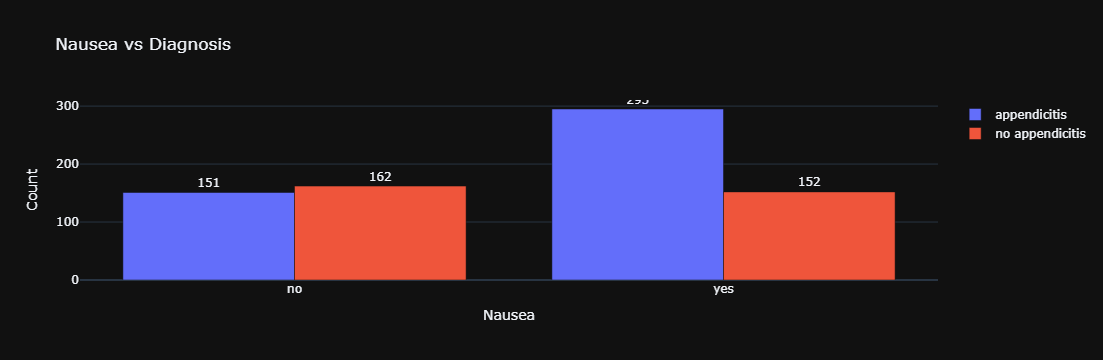

In [85]:

nausea_diagnosis_counts = df_cleaned.groupby(['Nausea', 'Diagnosis']).size().reset_index(name='Count')

# Step 2: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in nausea_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = nausea_diagnosis_counts[nausea_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Nausea'],  # Nausea categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Nausea vs Diagnosis",
    xaxis_title="Nausea",
    yaxis_title="Count",
    barmode='group',  # Group bars by Nausea and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\2080840288.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



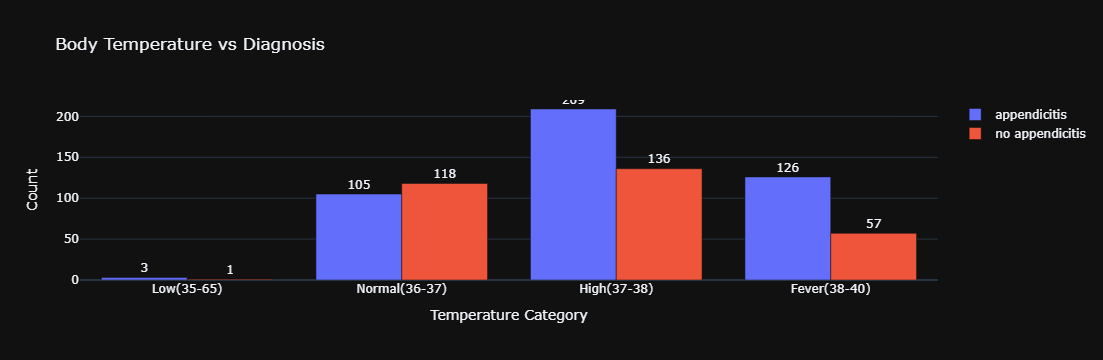

In [86]:

bins = [35, 36, 37, 38, 40]  # Define temperature categories (example ranges in Celsius)
labels = ['Low(35-65)', 'Normal(36-37)', 'High(37-38)', 'Fever(38-40)']  # Corresponding labels

df_cleaned['Temperature_Category'] = pd.cut(df_cleaned['Body_Temperature'], bins=bins, labels=labels, right=False)

# Step 2: Calculate the counts for each combination of 'Temperature_Category' and 'Diagnosis'
temperature_diagnosis_counts = df_cleaned.groupby(['Temperature_Category', 'Diagnosis']).size().reset_index(name='Count')

# Step 3: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in temperature_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = temperature_diagnosis_counts[temperature_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Temperature_Category'],  # Temperature categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Body Temperature vs Diagnosis",
    xaxis_title="Temperature Category",
    yaxis_title="Count",
    barmode='group',  # Group bars by Temperature category and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\2187127736.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



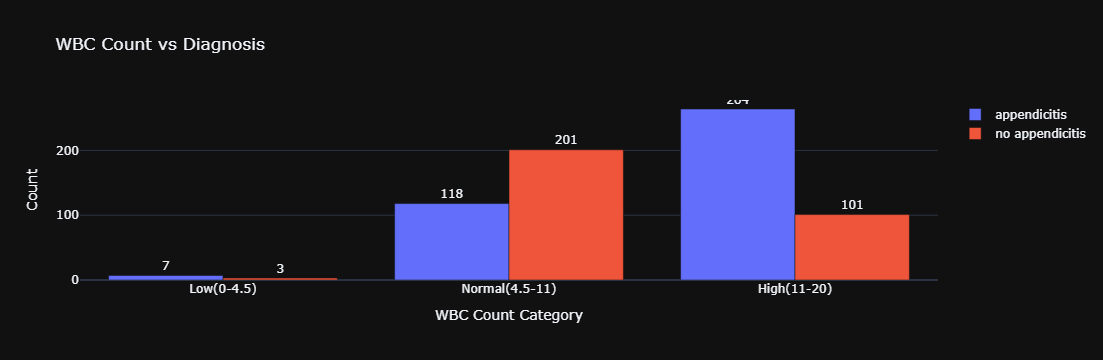

In [87]:

bins = [0, 4.5, 11, 20]  # Define the WBC count categories (normal ranges might differ)
labels = ['Low(0-4.5)', 'Normal(4.5-11)', 'High(11-20)']  # Corresponding labels

df_cleaned['WBC_Count_Category'] = pd.cut(df_cleaned['WBC_Count'], bins=bins, labels=labels, right=False)

# Step 2: Calculate the counts for each combination of 'WBC_Count_Category' and 'Diagnosis'
wbc_diagnosis_counts = df_cleaned.groupby(['WBC_Count_Category', 'Diagnosis']).size().reset_index(name='Count')

# Step 3: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in wbc_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = wbc_diagnosis_counts[wbc_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['WBC_Count_Category'],  # WBC count categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="WBC Count vs Diagnosis",
    xaxis_title="WBC Count Category",
    yaxis_title="Count",
    barmode='group',  # Group bars by WBC Count category and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()

C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\538238543.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



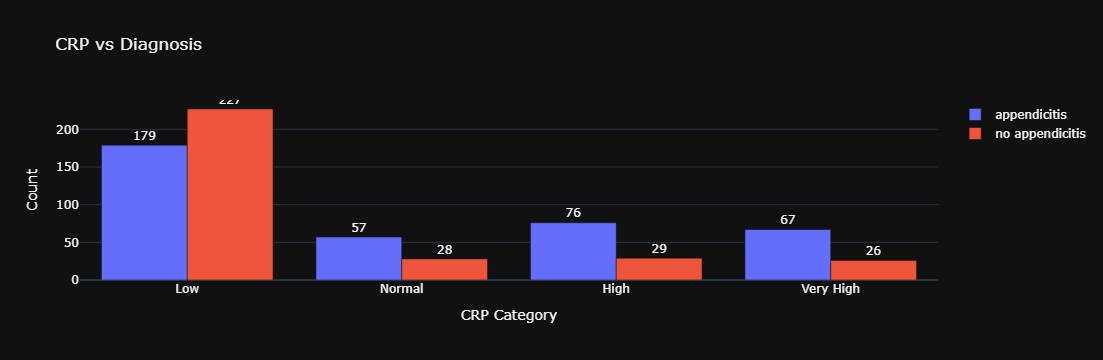

In [88]:

bins = [0, 10, 20, 40, 100]  # Define the CRP categories (these values can vary depending on your data)
labels = ['Low', 'Normal', 'High', 'Very High']  # Corresponding labels

df_cleaned['CRP_Category'] = pd.cut(df_cleaned['CRP'], bins=bins, labels=labels, right=False)

# Step 2: Calculate the counts for each combination of 'CRP_Category' and 'Diagnosis'
crp_diagnosis_counts = df_cleaned.groupby(['CRP_Category', 'Diagnosis']).size().reset_index(name='Count')

# Step 3: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in crp_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = crp_diagnosis_counts[crp_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['CRP_Category'],  # CRP categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="CRP vs Diagnosis",
    xaxis_title="CRP Category",
    yaxis_title="Count",
    barmode='group',  # Group bars by CRP category and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()


In [89]:
fluids_diagnosis_counts = df_cleaned.groupby(['Free_Fluids', 'Diagnosis']).size().reset_index(name='Count')

# Step 2: Create the bar plot
fig = go.Figure()

# Add a bar trace for each diagnosis category
for diagnosis in fluids_diagnosis_counts['Diagnosis'].unique():
    diagnosis_data = fluids_diagnosis_counts[fluids_diagnosis_counts['Diagnosis'] == diagnosis]
    fig.add_trace(go.Bar(
        x=diagnosis_data['Free_Fluids'],  # Free_Fluids categories
        y=diagnosis_data['Count'],  # Count of occurrences
        name=diagnosis,  # Diagnosis category as the bar label
        text=diagnosis_data['Count'],  # Display count values as text on top of bars
        textposition='outside'  # Position the text outside the bars
    ))

# Update layout
fig.update_layout(
    title="Free Fluids vs Diagnosis",
    xaxis_title="Free Fluids",
    yaxis_title="Count",
    barmode='group',  # Group bars by Free_Fluids and Diagnosis
    template="plotly_dark",  # Optional: for a dark theme
    uniformtext_minsize=8,
    uniformtext_mode='hide'
)

# Show the plot
fig.show()

In [90]:
import torch
from torchvision import models

# Load a pre-trained ResNet model
model = models.resnet50(pretrained=True)
model = model.eval()  # Set the model to evaluation mode
model = torch.nn.Sequential(*list(model.children())[:-1])

C:\Users\Syed Muhammad Muneeb\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

C:\Users\Syed Muhammad Muneeb\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.



In [91]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [92]:

# Function to extract image features using ResNet
def extract_features(image_path):
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Unable to read the image {image_path}")
        return None
    # Convert the image from BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    
    # Apply the transformation
    image = transform(image).unsqueeze(0)  # Add batch dimension
    if image.dim() != 4:  # Check if the image has the expected dimensions (batch, channels, height, width)
        #print('test')
        print(f"Warning: Unexpected dimensions for image {image_path}")
        return None
    
    # Extract features
    with torch.no_grad():
        features = model(image)
        
        features = features.squeeze().numpy() 
        #print(features)
    return features

In [93]:
# Function to parse the US_Number from the image file name
def parse_us_number(filename):
    match = re.match(r'^(\d+)\.', filename)
    if match:
        return int(match.group(1))
    return None

In [94]:

# Directory containing the images
image_dir = 'C:/Users/Syed Muhammad Muneeb/Downloads/DataMiningDS/US_Pictures/US_Pictures/'


In [95]:
# Display the shape of the cleaned dataframe
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)


Original shape: (760, 45)
Cleaned shape: (760, 45)


In [96]:
# Display the shape of the cleaned dataframe
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)


Original shape: (760, 45)
Cleaned shape: (760, 45)


In [97]:
us_number_to_features = {}

# Process all images and extract features
for image_file in os.listdir(image_dir):
    image_path = os.path.join(image_dir, image_file)
    us_number = parse_us_number(image_file)
    
    if us_number is not None:
        features = extract_features(image_path)
        if features is not None:
            if us_number not in us_number_to_features:
                us_number_to_features[us_number] = []
            us_number_to_features[us_number].append(features)

# Create a DataFrame to hold all features with dynamic column naming
all_features_df = pd.DataFrame()

for us_number, features_list in us_number_to_features.items():
    # Create a dictionary for storing feature columns for this US_Number
    feature_columns = {}
    for i, features in enumerate(features_list):
        # Add each feature vector to separate columns
        for j, feature_value in enumerate(features):
            column_name = f'Image_{i+1}_Feature_{j+1}'
            feature_columns[column_name] = feature_value
    # Convert to a DataFrame and add US_Number
    temp_df = pd.DataFrame([feature_columns])
    temp_df['US_Number'] = us_number
    # Append to the main DataFrame
    all_features_df = pd.concat([all_features_df, temp_df], ignore_index=True)





In [98]:
# Merge the features DataFrame with the original tabular data
merged_data = pd.merge(df_cleaned, all_features_df, on='US_Number', how='left')

In [125]:
# Save the merged data to a new CSV file
merged_data.to_csv('C:/Users/Syed Muhammad Muneeb/Downloads/DataMiningDS/merged_data_with_image_features.csv', index=False)

print("Feature extraction and merging completed. The results are saved in 'merged_data_with_image_features.csv'.")

Feature extraction and merging completed. The results are saved in 'merged_data_with_image_features.csv'.


In [126]:
df = pd.read_csv('C:/Users/Syed Muhammad Muneeb/Downloads/DataMiningDS/merged_data_with_image_features.csv')

In [127]:
# Calculate the threshold for 60% null values
threshold = len(df) * 0.6

# Drop columns where the number of null values exceeds the threshold
df_cleaned = df.loc[:, df.isnull().sum() <= threshold]

# Display the shape of the cleaned dataframe
print("Original shape:", df.shape)
print("Cleaned shape:", df_cleaned.shape)

Original shape: (760, 38957)
Cleaned shape: (760, 4141)


In [128]:
df = df_cleaned

In [129]:
null_columns_sum = df_cleaned.isnull().sum()

# Filter only the columns that have null values
null_columns_sum = null_columns_sum[null_columns_sum > 0]

# Display the columns with null values and their sum
print(null_columns_sum)

Alvarado_Score_Category     23
Temperature_Category         5
WBC_Count_Category          66
CRP_Category                71
Image_1_Feature_1          182
                          ... 
Image_2_Feature_2044       360
Image_2_Feature_2045       360
Image_2_Feature_2046       360
Image_2_Feature_2047       360
Image_2_Feature_2048       360
Length: 4100, dtype: int64


In [130]:
#BMI_Category	Alvarado_Score_Category	Temperature_Category	WBC_Count_Category	CRP_Category
all_columns = df_cleaned.columns.tolist()
categorical_features = ['Sex', 'BMI_Category','CRP_Category', 'WBC_Count_Category', 'Temperature_Category', 'Alvarado_Score_Category', 'Migratory_Pain', 'US_Performed', 'Ipsilateral_Rebound_Tenderness', 'Lower_Right_Abd_Pain', 'Coughing_Pain', 'Nausea']
numerical_features = [ 'Paedriatic_Appendicitis_Score', 'Neutrophil_Percentage'] + [col for col in all_columns if col.startswith('Image')]


In [131]:
# Remove rows where 'US_Number' has null values
df = df.dropna(subset=['US_Number'])


# Fill null values in numerical columns with the mean
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())



# Verify if nulls have been filled
print("Null values in numerical columns after filling:")
#print(df[numerical_columns].isnull().sum())


# Fill null values in categorical columns with the mode
df[categorical_columns] = df[categorical_columns].apply(lambda col: col.fillna(col.mode()[0]))



# Verify if nulls have been filled
print("Null values in categorical columns after filling:")
#print(df[categorical_columns].isnull().sum())


Null values in numerical columns after filling:
Null values in categorical columns after filling:


In [132]:
df = df.dropna(axis=1, thresh=len(df) - 600)


In [133]:
selected_columns_df = df[['Sex', 'US_Number', 'Migratory_Pain','Alvarado_Score', 'Body_Temperature','Paedriatic_Appendicitis_Score', 'WBC_Count', 'Neutrophil_Percentage', 'CRP', 'BMI', 'Height', 'Weight', 'US_Performed', 'Ipsilateral_Rebound_Tenderness', 'Lower_Right_Abd_Pain', 'Coughing_Pain', 'Nausea']]

# removing nulls from US_Number

# null values in current data set

In [134]:
df_training=df[categorical_features + ['Diagnosis']]

In [135]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Apply label encoding to each categorical feature
for col in categorical_features:
    df_training[col] = label_encoder.fit_transform(df_training[col])

C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\3359408275.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\3359408275.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\3359408275.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [136]:
from ydata_profiling import ProfileReport
profile = ProfileReport(
    df_training,
    title="Sampled Profiling Report",
    minimal=True,
    correlations=None,  # Disable all correlations
    interactions=None,  # Disable interactions
    missing_diagrams=None,  # Disable missing values diagrams
)

In [137]:
profile.to_file('report.html')

C:\Users\Syed Muhammad Muneeb\anaconda3\Lib\site-packages\ydata_profiling\utils\dataframe.py:137: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify numerical and categorical columns
'''all_columns = df_cleaned.columns.tolist()

categorical_features = ['Sex', 'Migratory_Pain', 'US_Performed', 'Ipsilateral_Rebound_Tenderness', 'Lower_Right_Abd_Pain', 'Coughing_Pain', 'Nausea']
numerical_features = [ 'Alvarado_Score', 'Body_Temperature','Paedriatic_Appendicitis_Score', 'WBC_Count', 'Neutrophil_Percentage', 'CRP', 'BMI', 'Height', 'Weight'] + [col for col in all_columns if col.startswith('Image')]
'''

# Preprocessing pipeline
'''preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ])'''
#df_training[numerical_features] = df_training[numerical_features].fillna(df[numerical_features].mean())
# Apply preprocessing
X_tabular = df_training.drop(columns=['Diagnosis'])
y = df_training['Diagnosis']  # Assuming 'Diagnosis' is the target

# Now X_tabular is the preprocessed features and y is the target


In [139]:
X_tabular

,Sex,BMI_Category,CRP_Category,WBC_Count_Category,Temperature_Category,Alvarado_Score_Category,Migratory_Pain,US_Performed,Ipsilateral_Rebound_Tenderness,Lower_Right_Abd_Pain,Coughing_Pain,Nausea
0,0,3,1,2,1,1,0,1,0,1,0,0
1,1,1,1,2,3,1,1,1,0,1,0,0
2,0,0,1,0,3,1,0,1,0,1,0,0
3,0,0,1,0,3,2,1,1,0,1,0,1
4,0,3,1,2,3,1,0,1,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
755,1,0,3,3,0,2,0,1,0,1,0,1
756,0,2,3,0,0,0,1,1,0,1,0,0
757,0,0,1,0,1,1,0,1,0,1,0,0
758,1,3,1,0,1,0,1,1,0,1,1,1


In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tabular, y, test_size=0.2, random_state=42)


# Check for NaN values in X_train
#print("Number of NaN values in X_train:", np.isnan(X_train).sum())

#print("Data type of y_train:", type(y_train))



from sklearn.preprocessing import LabelEncoder

# Encode labels if y_train is non-numeric
if not np.issubdtype(y_train.dtype, np.number):
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)
    y_test = le.transform(y_test)  # Apply the same transformation to y_test

#print("Number of NaN values in y_train:", np.isnan(y_train).sum())


In [141]:
# Train the model
model_randomforest = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 2},random_state=42)
model_randomforest.fit(X_train, y_train)

# Predict and evaluate
y_pred = model_randomforest.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.73      0.79      0.76        95
           1       0.59      0.51      0.55        57

    accuracy                           0.68       152
   macro avg       0.66      0.65      0.65       152
weighted avg       0.68      0.68      0.68       152



In [143]:
import matplotlib.pyplot as plt
tree = model_randomforest.estimators_[0]
from sklearn.tree import plot_tree

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=[f"Feature {i}" for i in range(X_tabular.shape[1])], class_names=["Class 0", "Class 1"])
plt.title("Decision Tree from Random Forest")
plt.show()

C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\3821430099.py:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [145]:
importances = model_randomforest.feature_importances_
indices = np.argsort(importances)[::-1]

# Print feature ranking
for i in range(len(importances)):
    print(f"{i + 1}. feature {indices[i]} ({importances[indices[i]]})")


1. feature 2 (0.21142855166987812)
2. feature 5 (0.15498654976202536)
3. feature 4 (0.11894452319532788)
4. feature 3 (0.11859815822160566)
5. feature 1 (0.0955905176562359)
6. feature 0 (0.0691577465307845)
7. feature 6 (0.06330730785775254)
8. feature 11 (0.05686269738546588)
9. feature 10 (0.056061301479639156)
10. feature 9 (0.025934327720199712)
11. feature 8 (0.02159752641512112)
12. feature 7 (0.0075307921059641)


In [146]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


C:\Users\Syed Muhammad Muneeb\AppData\Local\Temp\ipykernel_40696\3565726571.py:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [147]:
from sklearn.metrics import accuracy_score

# Calculate accuracy using sklearn's function
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.68


In [148]:
conf_matrix

array([[75, 20],
       [28, 29]], dtype=int64)

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

# Train the model using Logistic Regression
model_logistic = LogisticRegression(random_state=42, max_iter=1000)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Fit the model on the training data
model_logistic.fit(X_scaled, y_train)

# Predict on the test data
y_pred = model_logistic.predict(X_test)

# Print classification report to evaluate the model
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.70      0.92      0.79        95
           1       0.70      0.33      0.45        57

    accuracy                           0.70       152
   macro avg       0.70      0.62      0.62       152
weighted avg       0.70      0.70      0.66       152



C:\Users\Syed Muhammad Muneeb\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning:

X has feature names, but LogisticRegression was fitted without feature names



In [153]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Train the model using SVM
model_SVC = SVC(random_state=42)

# Fit the model on the training data
model_SVC.fit(X_train, y_train)

# Predict on the test data
y_pred = model_SVC.predict(X_test)

# Print classification report to evaluate the model
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.76      0.81      0.79        95
           1       0.65      0.58      0.61        57

    accuracy                           0.72       152
   macro avg       0.70      0.69      0.70       152
weighted avg       0.72      0.72      0.72       152



In [154]:
x_min, x_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
y_min, y_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1


In [155]:
print("X shape:", X_tabular.shape)
print("y shape:", y_train.shape)
print("Support vectors shape:", model.support_vectors_.shape)

X shape: (760, 12)
y shape: (608,)
Support vectors shape: (435, 12)
